# Laboratory practice 2.3: Classification III

For this practice, you will need the following datasets:

- **Simdata.dat**: synthetic datasets containing several input variables and one output variable **Y**.

The main package for machine learning in Python is **scikit-learn**.

Further reading:
- [scikit-learn](https://scikit-learn.org)

In addition, we will be using the following libraries:
- Data management
    - [numpy](https://numpy.org/)
    - [pandas](https://pandas.pydata.org/)

- Plotting
    - [seaborn](https://seaborn.pydata.org/)
    - [matplotlib](https://matplotlib.org/)

- Model analysis
    - [scipy](https://scipy.org/)


In [7]:
### Load necessary modules -------------------------------
# interactive plotting
%matplotlib inline
%config InlineBackend.figure_format = 'svg' # ‘png’, ‘retina’, ‘jpeg’, ‘svg’, ‘pdf’

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

# Data management libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Machine learning libraries
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# others
from utils import *

---
## 1. Prepare the Dataset

In [10]:
### Load file --------------------------------------------
df = pd.read_csv('Simdata.dat', sep = "\t")
df.head()

,X1,X2,Y
0,-3.745291,3.729409,NO
1,5.806532,-4.703332,YES
2,4.209833,-0.493488,YES
3,3.429156,-2.307669,NO
4,-0.195014,2.680303,NO


In [12]:
#There are no categorical input variables

### Convert output variable to factor
df.Y = df.Y.astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   X1      1000 non-null   float64 
 1   X2      1000 non-null   float64 
 2   Y       1000 non-null   category
dtypes: category(1), float64(2)
memory usage: 16.9 KB


In [14]:
# Define input and output matrices
INPUTS = ['X1','X2']
OUTPUT = 'Y'
X = df[INPUTS]
y = df[OUTPUT]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,  #percentage of test data
                                                    random_state=0, #seed for replication
                                                    stratify = y)   #Preserves distribution of y

In [16]:
## Create dataset to store model predictions
dfTR_eval = X_train.copy()
dfTR_eval['Y'] = y_train # We will call Y as output variable for simplicity
dfTS_eval = X_test.copy()
dfTS_eval['Y'] = y_test # We will call Y as output variable for simplicity

---

## 2. Training of Machine Learning models

### Decision Trees

- [DecisionTreeClassifier()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Wikipedia](https://en.wikipedia.org/wiki/Decision_tree)

In [21]:
#-------------------------------------------------------------------------------------------------
#---------------------------- DECISION TREE MODEL ------------------------------------------------
#-------------------------------------------------------------------------------------------------


################################################################################################
#Entrenamiento basado en pipelines, al igual que los casos anteriores.


## Inputs of the model. Change accordingly to perform variable selection
INPUTS_DT = INPUTS

param = {'DT__min_impurity_decrease': np.arange(0,0.05,0.005)} # Minimum entropy to decrease in each split
#param = {'DT__min_impurity_decrease': [0.02]} # Minimum entropy to decrease in each split
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('DT', DecisionTreeClassifier(criterion='gini',  # impuriry measure
                                                     min_samples_split=5, # Minimum number of obs in node to keep cutting.  Impide dividir nodos con menos de 5 observaciones, ayudando a controlar la profundidad del árbol.
                                                     min_samples_leaf=5, # Minimum number of obs in a terminal node. Asegura que los nodos terminales tengan al menos 5 observaciones, haciendo que el árbol no se sobreajuste a pequeñas muestras de datos.
                                                     random_state=150))]) # For replication

#Definimos cross-validation. Máxima entropía porque no hay solape.

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
tree_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
tree_fit.fit(X_train[INPUTS_DT], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('DT',
                                        DecisionTreeClassifier(min_samples_leaf=5,
                                                               min_samples_split=5,
                                                               random_state=150))]),
             n_jobs=-1,
             param_grid={'DT__min_impurity_decrease': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045])},
             scoring='accuracy')

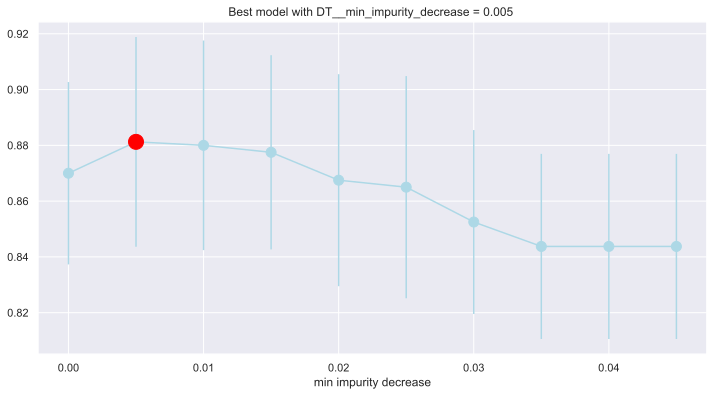

In [23]:
plotModelGridError(tree_fit)

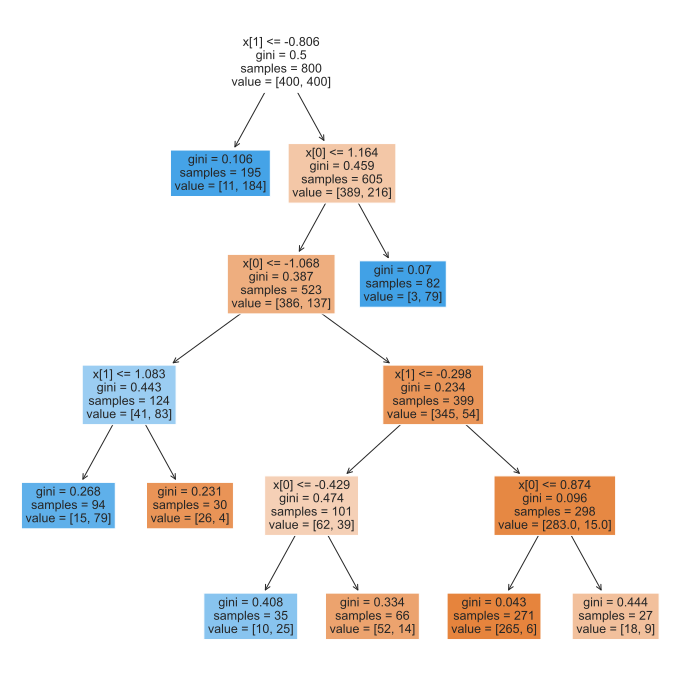

In [25]:
## Plot the decision tree model
plt.figure(figsize=(12, 12))
plot_tree(tree_fit.best_estimator_['DT'], filled=True)
plt.show()
#Interpretacion de la informacion que hay sobre un nodo:
#La condición es x[1] <= -0.806, lo que significa que la característica x[1] se usa para dividir las observaciones.
#El índice de Gini es 0.5, lo que indica que las observaciones en ese nodo están equitativamente divididas entre las dos clases (impureza máxima).
#Hay 800 muestras en total, y el valor es [400, 400], lo que significa que hay exactamente 400 observaciones de cada clase.


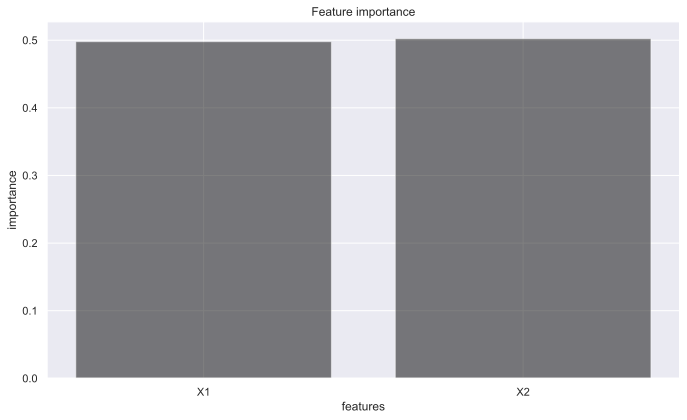

In [27]:
## Plot the variable importance of each feature
plt.figure(figsize=(6 * 1.618, 6))
index = np.arange(len(X_train[INPUTS_DT].columns))
bar_width = 0.35
plt.bar(index, tree_fit.best_estimator_['DT'].feature_importances_, color='black', alpha=0.5)
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Feature importance')
plt.xticks(index, X_train[INPUTS_DT].columns)
plt.tight_layout()
plt.show()

In [29]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_DT_pred'] = tree_fit.predict(X_train[INPUTS_DT])
dfTR_eval['Y_DT_prob_neg'] = tree_fit.predict_proba(X_train[INPUTS_DT])[:,0]
dfTR_eval['Y_DT_prob_pos'] = tree_fit.predict_proba(X_train[INPUTS_DT])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_DT_pred'] = tree_fit.predict(X_test[INPUTS_DT])
dfTS_eval['Y_DT_prob_neg'] = tree_fit.predict_proba(X_test[INPUTS_DT])[:,0]
dfTS_eval['Y_DT_prob_pos'] = tree_fit.predict_proba(X_test[INPUTS_DT])[:,1]

#visualize evaluated data
dfTR_eval.head()

,X1,X2,Y,Y_DT_pred,Y_DT_prob_neg,Y_DT_prob_pos
601,4.155807,2.247574,YES,YES,0.036585,0.963415
717,-4.089190,-0.989964,YES,YES,0.159574,0.840426
20,-2.278323,-0.817837,YES,NO,0.977860,0.022140
523,4.207323,2.378063,YES,YES,0.036585,0.963415
344,-3.139076,-2.136547,YES,YES,0.285714,0.714286


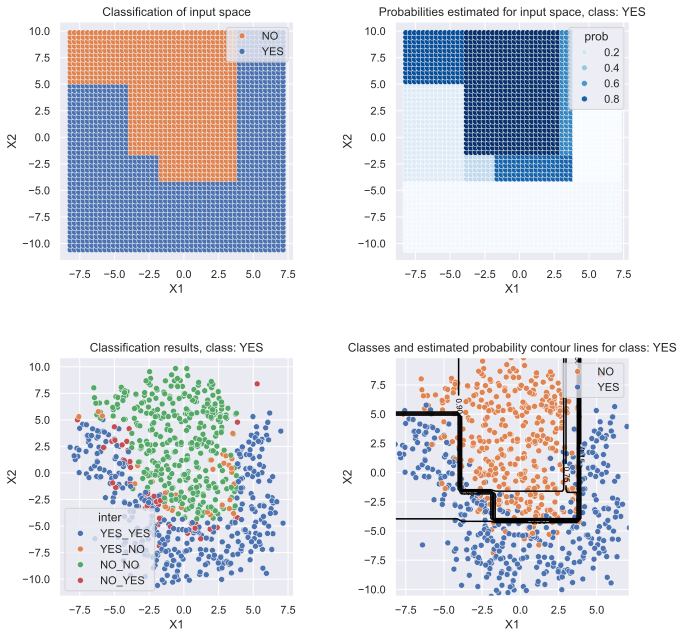

In [32]:
### Plot classification in a 2 dimensional space
plot2DClass(X_train[INPUTS_DT], dfTR_eval['Y'], tree_fit, 'X1', 'X2', 'YES', 50, (10, 10)) 

In [34]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_DT_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 361   39
      YES  33  367

Accuracy: 0.91
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.82
Mcnemar's Test P-Value: 0.56
Sensitivity: 0.92
Specificity: 0.9
Precision: 0.92
Recall: 0.9
Prevalence: 0.5
Detection Rate: 0.46
Detection prevalence: 0.51
Balanced accuracy: 0.91
F1 Score: 0.91
Positive label: NO


In [36]:
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_DT_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  87   13
      YES  18   82

Accuracy: 0.84
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.69
Mcnemar's Test P-Value: 0.47
Sensitivity: 0.82
Specificity: 0.87
Precision: 0.83
Recall: 0.87
Prevalence: 0.5
Detection Rate: 0.41
Detection prevalence: 0.48
Balanced accuracy: 0.84
F1 Score: 0.85
Positive label: NO


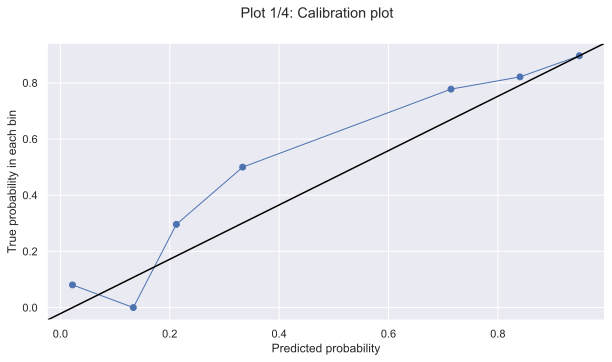

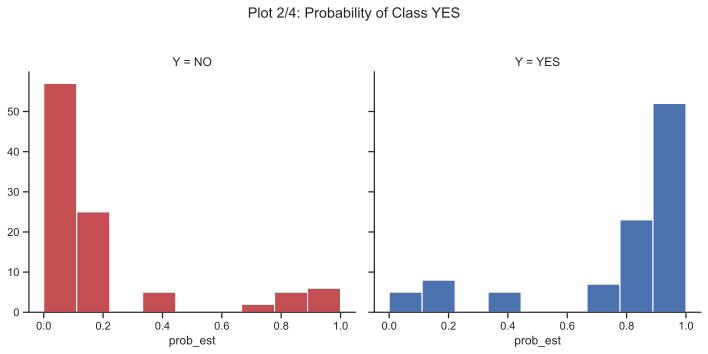

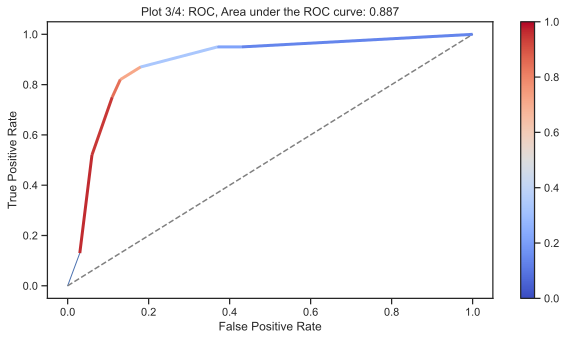

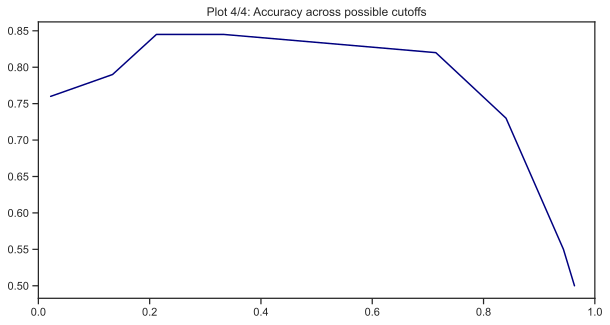

In [38]:
plotClassPerformance(dfTS_eval['Y'], tree_fit.predict_proba(X_test[INPUTS_DT]), selClass='YES')

### Random Forest

- [RandomForestClassifier()](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)
- [Wikipedia](https://en.wikipedia.org/wiki/Random_forest)

In [40]:
# Un random forest es un conjunto (ensamble) de muchos árboles de decisión. En lugar de entrenar un solo árbol, se entrenan muchos 
# (por ejemplo, 100, 200 o más). Cada uno de estos árboles es entrenado con un subconjunto diferente de los datos de entrenamiento y, 
# además, selecciona aleatoriamente un conjunto de variables para considerar en cada división del árbol.
# Las predicciones del random forest se obtienen haciendo un promedio (en el caso de regresión) o un voto mayoritario 
# (en el caso de clasificación) de las predicciones de todos los árboles individuales.



## Inputs of the model. Change accordingly to perform variable selection
INPUTS_RF = INPUTS

#Indica el número de árboles de decisión que se van a entrenar y ensamblar para formar el modelo de Random Forest.
param = {'RF__n_estimators': range(10, 200, 10)} #Number of trees to grow
pipe = Pipeline(steps=[('scaler', StandardScaler()), 
                       ('RF', RandomForestClassifier(criterion='gini', # impuriry measure
                                                    max_features=len(X_train.columns),  # number of variables randomly sampled as candidates at each split.
                                                    min_samples_split=5,  # Minimum number of obs in node to keep cutting
                                                    min_samples_leaf=5, # Minimum number of obs in a terminal node
                                                    random_state=150))]) # For replication

# We use Grid Search Cross Validation to find the best parameter for the model in the grid defined 
nFolds = 10
rf_fit = GridSearchCV(estimator=pipe, # Structure of the model to use
                       param_grid=param, # Defined grid to search in
                       n_jobs=-1, # Number of cores to use (parallelize)
                       scoring='accuracy', # Accuracy https://scikit-learn.org/stable/modules/model_evaluation.html
                       cv=nFolds) # Number of Folds 
rf_fit.fit(X_train[INPUTS_RF], y_train) # Search in grid

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('RF',
                                        RandomForestClassifier(max_features=2,
                                                               min_samples_leaf=5,
                                                               min_samples_split=5,
                                                               random_state=150))]),
             n_jobs=-1, param_grid={'RF__n_estimators': range(10, 200, 10)},
             scoring='accuracy')

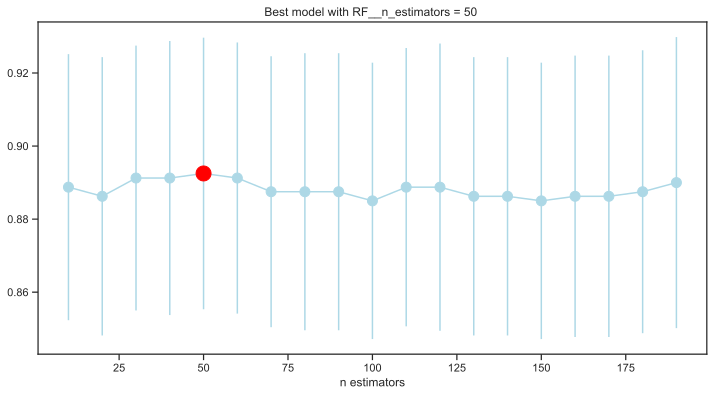

In [42]:
plotModelGridError(rf_fit)

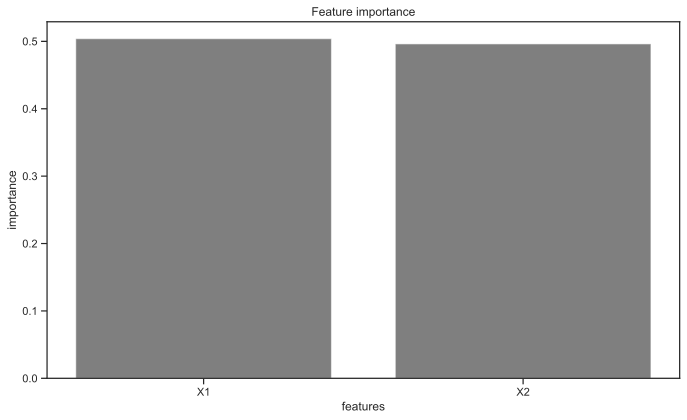

In [44]:
## Plot the variable importance of each feature
plt.figure(figsize=(6 * 1.618, 6))
index = np.arange(len(X_train[INPUTS_RF].columns))
bar_width = 0.35
plt.bar(index, rf_fit.best_estimator_['RF'].feature_importances_, color='black', alpha=0.5)
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Feature importance')
plt.xticks(index, X_train.columns)
plt.tight_layout()
plt.show()

In [46]:
## Obtain a report of the model based on predictions ---------------------------------------------
dfTR_eval['Y_RF_pred'] = rf_fit.predict(X_train[INPUTS_RF])
dfTR_eval['Y_RF_prob_neg'] = rf_fit.predict_proba(X_train[INPUTS_RF])[:,0]
dfTR_eval['Y_RF_prob_pos'] = rf_fit.predict_proba(X_train[INPUTS_RF])[:,1]
### Scale test using preprocess in training
dfTS_eval['Y_RF_pred'] = rf_fit.predict(X_test[INPUTS_RF])
dfTS_eval['Y_RF_prob_neg'] = rf_fit.predict_proba(X_test[INPUTS_RF])[:,0]
dfTS_eval['Y_RF_prob_pos'] = rf_fit.predict_proba(X_test[INPUTS_RF])[:,1]

dfTR_eval.head()

,X1,X2,Y,Y_DT_pred,Y_DT_prob_neg,Y_DT_prob_pos,Y_RF_pred,Y_RF_prob_neg,Y_RF_prob_pos
601,4.155807,2.247574,YES,YES,0.036585,0.963415,YES,0.000000,1.000000
717,-4.089190,-0.989964,YES,YES,0.159574,0.840426,YES,0.178856,0.821144
20,-2.278323,-0.817837,YES,NO,0.977860,0.022140,NO,0.783784,0.216216
523,4.207323,2.378063,YES,YES,0.036585,0.963415,YES,0.000000,1.000000
344,-3.139076,-2.136547,YES,YES,0.285714,0.714286,YES,0.165430,0.834570


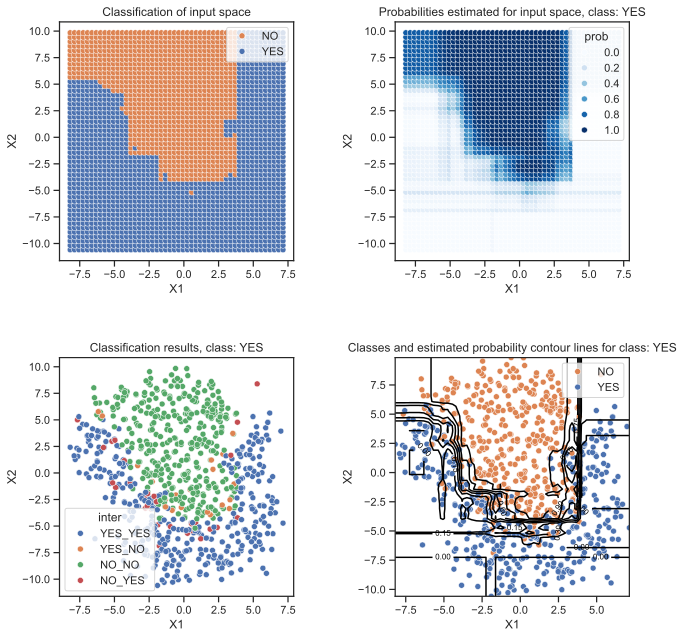

In [48]:
### Plot classification in a 2 dimensional space
plot2DClass(X_train[INPUTS_RF], dfTR_eval['Y'], rf_fit, 'X1', 'X2', 'YES', 50) 

In [50]:
confusion_matrix(dfTR_eval['Y'], dfTR_eval['Y_RF_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO 371   29
      YES  21  379

Accuracy: 0.94
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.88
Mcnemar's Test P-Value: 0.32
Sensitivity: 0.95
Specificity: 0.93
Precision: 0.95
Recall: 0.93
Prevalence: 0.5
Detection Rate: 0.47
Detection prevalence: 0.51
Balanced accuracy: 0.94
F1 Score: 0.94
Positive label: NO


In [52]:
confusion_matrix(dfTS_eval['Y'], dfTS_eval['Y_RF_pred'], labels=['NO','YES'])

Confusion Matrix and Statistics
	   Prediction
Reference  NO  YES
       NO  89   11
      YES  17   83

Accuracy: 0.86
No Information Rate: 0.5
P-Value [Acc > NIR]: 0.0
Kappa: 0.72
Mcnemar's Test P-Value: 0.34
Sensitivity: 0.83
Specificity: 0.89
Precision: 0.84
Recall: 0.89
Prevalence: 0.5
Detection Rate: 0.42
Detection prevalence: 0.47
Balanced accuracy: 0.86
F1 Score: 0.86
Positive label: NO


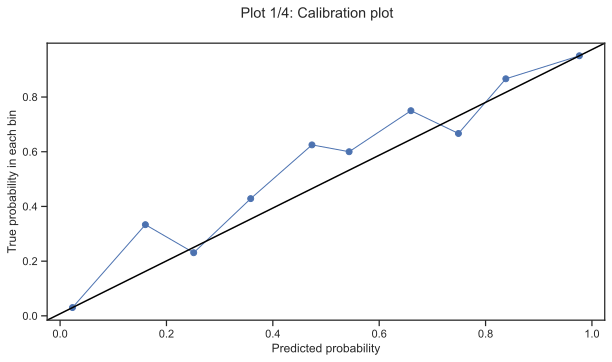

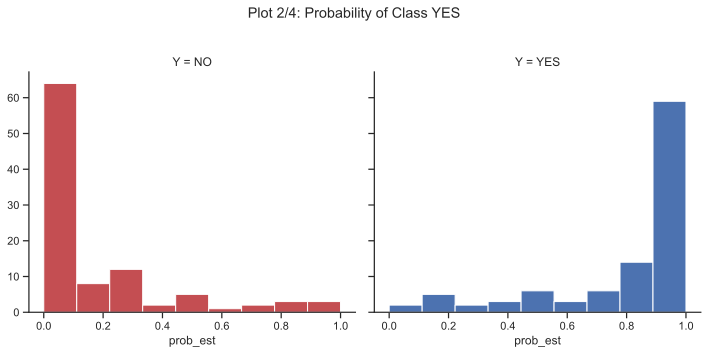

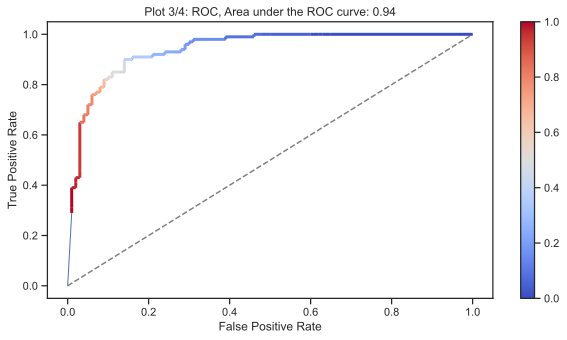

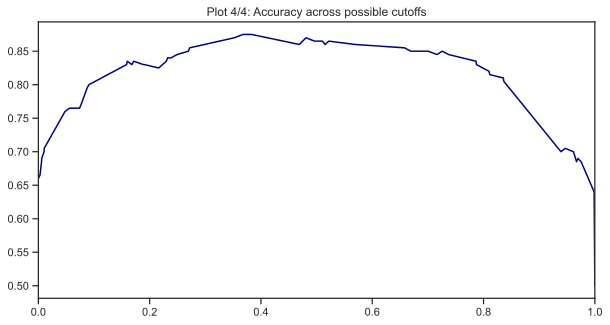

In [54]:
plotClassPerformance(dfTS_eval['Y'], rf_fit.predict_proba(X_test[INPUTS_RF]), selClass='YES')

### XGBoost

- [xgboost](https://xgboost.readthedocs.io/en/stable/)
- [Wikipedia](https://en.wikipedia.org/wiki/XGBoost)